# Nonparametric Collapsed Gibbs sampling

In [1]:
import numpy as np
from collections import Counter

import matplotlib.pyplot as plt

In [2]:
from nonparametric_collapsed_gibbs import CollapsedGibbsDP
from gibbs_plots import plot_clustered_1d, plot_clustered_2d

%load_ext autoreload
%autoreload 2

In [3]:
FONTSIZE=16
LABELSIZE=0.9*FONTSIZE
LINEWIDTH=2.0
FIGWIDTH=8
ASPECT_RATIO=4/3

plt.rcParams['axes.labelsize'] = FONTSIZE
plt.rcParams['axes.linewidth'] = LINEWIDTH
plt.rcParams['axes.titlesize'] = 1.1*FONTSIZE
plt.rcParams['figure.figsize'] = [FIGWIDTH, FIGWIDTH/ASPECT_RATIO]
plt.rcParams['figure.labelsize'] = FONTSIZE
plt.rcParams['figure.titlesize'] = 1.1*FONTSIZE
plt.rcParams['legend.fancybox'] = False
plt.rcParams['legend.framealpha'] = 1.0
plt.rcParams['legend.fontsize'] = LABELSIZE
plt.rcParams['legend.title_fontsize'] = LABELSIZE
plt.rcParams['patch.linewidth'] = LINEWIDTH
plt.rcParams['lines.linewidth'] = LINEWIDTH
plt.rcParams['xtick.labelsize'] = LABELSIZE
plt.rcParams['ytick.labelsize'] = LABELSIZE
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['figure.autolayout'] = True

plt.rcParams['patch.edgecolor'] = 'black'

In [4]:
DATA_PATH = "../GRBs/GRB_data.txt"
arr = np.loadtxt(DATA_PATH, skiprows=1)
logT90 = arr[:,0]
sigma_logT90 = arr[:,1]

In [20]:
np.array([logT90,sigma_logT90]).T.shape

(1932, 2)

In [5]:
import pickle

def save_state_pickle(st, filename):
    """Save `st` to filename using pickle."""
    with open(filename, "wb") as f:
        pickle.dump(st, f, protocol=pickle.HIGHEST_PROTOCOL)

def load_state_pickle(filename):
    """Load state (created by save_state_pickle)."""
    with open(filename, "rb") as f:
        st = pickle.load(f)
    return st

In [11]:
%%time
LOAD   = 1  
alpha  = 0.01
kappa0 = 0.1

if LOAD == 0:
    # instantiate collapsed Gibbs sampler with weak NIG prior
    rng_gen = np.random.default_rng(1234)
    mid_range = (np.max(logT90) - np.min(logT90))/2.0
    sampler = CollapsedGibbsDP(logT90, alpha=alpha, mu0=mid_range, 
                               kappa0=kappa0, alpha0=2.0, beta0=4.0, 
                               init_clusters=2, rng_gen=rng_gen)
    print("Initial number of clusters:", len(sampler.cluster_ids_))
    sampler.run(1000, verbose=True)
    st = sampler.get_state()
    print("Final num clusters:", len(st['cluster_ids_']))
    print("Counts:", Counter(st['assignment']))

    save_state_pickle(st, f'../chains/assigment_alpha={alpha}_kappa0={kappa0}.pkl')
else:
    st = load_state_pickle(f'../chains/assigment_alpha={alpha}_kappa0={kappa0}.pkl')

CPU times: user 370 µs, sys: 0 ns, total: 370 µs
Wall time: 381 µs


__N_Iter = 1000, alpha=0.1, kappa0=0.1:__ (37min 59s)

    Initial number of clusters: 2
    Iter 100/1000   num_clusters=2   counts={1: 578, 0: 1354}
    Iter 200/1000   num_clusters=2   counts={0: 1329, 1: 603}
    Iter 300/1000   num_clusters=2   counts={1: 593, 0: 1339}
    Iter 400/1000   num_clusters=2   counts={0: 1292, 1: 640}
    Iter 500/1000   num_clusters=2   counts={0: 1312, 1: 620}
    Iter 600/1000   num_clusters=3   counts={2: 552, 0: 982, 1: 398}
    Iter 700/1000   num_clusters=3   counts={1: 469, 0: 1042, 2: 421}
    Iter 800/1000   num_clusters=3   counts={2: 570, 0: 934, 1: 428}
    Iter 900/1000   num_clusters=3   counts={0: 1142, 2: 346, 1: 444}
    Iter 1000/1000   num_clusters=3   counts={2: 533, 0: 969, 1: 430}
    Final num clusters: 3
    Counts: Counter({0: 969, 2: 533, 1: 430})
    Mean Cluster 0  = 3.770 	Sigma Cluster 0 = 0.905
    Mean Cluster 1  = -0.819 	Sigma Cluster 1 = 1.092
    Mean Cluster 2  = 2.349 	Sigma Cluster 2 = 1.231

__N_Iter = 1000, alpha=0.01, kappa0=0.1:__ (30min 59s)

    Initial number of clusters: 2
    Iter 100/1000   num_clusters=2   counts={1: 578, 0: 1354}
    Iter 200/1000   num_clusters=2   counts={0: 1329, 1: 603}
    Iter 300/1000   num_clusters=2   counts={1: 593, 0: 1339}
    Iter 400/1000   num_clusters=2   counts={0: 1292, 1: 640}
    Iter 500/1000   num_clusters=2   counts={0: 1312, 1: 620}
    Iter 600/1000   num_clusters=2   counts={0: 1271, 1: 661}
    Iter 700/1000   num_clusters=2   counts={0: 1319, 1: 613}
    Iter 800/1000   num_clusters=2   counts={0: 1298, 1: 634}
    Iter 900/1000   num_clusters=2   counts={0: 1281, 1: 651}
    Iter 1000/1000   num_clusters=2   counts={0: 1329, 1: 603}
    Final num clusters: 2
    Mean Cluster 0  = 3.538 	Sigma Cluster 0 = 0.996
    Mean Cluster 1  = -0.246 	Sigma Cluster 1 = 1.370

__N_Iter = 1000, alpha=1, kappa0=0.1:__ (1h 19min 3s)

    Initial number of clusters: 2
    Iter 100/1000   num_clusters=4   counts={2: 216, 0: 1071, 1: 512, 8: 133}
    Iter 200/1000   num_clusters=6   counts={1: 560, 0: 686, 14: 173, 21: 55, 2: 456, 22: 2}
    Iter 300/1000   num_clusters=6   counts={14: 163, 0: 908, 1: 552, 2: 270, 15: 35, 16: 4}
    Iter 400/1000   num_clusters=6   counts={0: 732, 1: 535, 14: 569, 2: 75, 18: 19, 19: 2}
    Iter 500/1000   num_clusters=5   counts={0: 726, 14: 652, 1: 502, 18: 50, 23: 2}
    Iter 600/1000   num_clusters=10   counts={18: 157, 14: 840, 24: 103, 42: 198, 1: 294, 0: 94, 29: 117, 41: 118, 44: 8, 45: 3}
    Iter 700/1000   num_clusters=5   counts={14: 825, 42: 428, 29: 260, 1: 262, 18: 157}
    Iter 800/1000   num_clusters=5   counts={42: 690, 14: 788, 43: 21, 1: 313, 29: 120}
    Iter 900/1000   num_clusters=8   counts={14: 1174, 1: 155, 60: 3, 42: 179, 29: 236, 49: 101, 57: 67, 59: 17}
    Iter 1000/1000   num_clusters=7   counts={14: 922, 57: 218, 42: 329, 58: 83, 29: 368, 1: 11, 71: 1}
    Final num clusters: 7
    Mean Cluster 1  = 1.614 	Sigma Cluster 1 = 1.955
    Mean Cluster 14  = 3.534 	Sigma Cluster 14 = 0.900
    Mean Cluster 29  = -1.025 	Sigma Cluster 29 = 1.023
    Mean Cluster 42  = 1.323 	Sigma Cluster 42 = 0.960
    Mean Cluster 57  = 4.174 	Sigma Cluster 57 = 0.846
    Mean Cluster 58  = 3.670 	Sigma Cluster 58 = 0.727
    Mean Cluster 71  = 4.282 	Sigma Cluster 71 = 0.000

__N_Iter = 1000, alpha=0.1, kappa0=0.01:__ (35min 8s)

    Initial number of clusters: 2
    Iter 100/1000   num_clusters=2   counts={1: 578, 0: 1354}
    Iter 200/1000   num_clusters=2   counts={0: 1329, 1: 603}
    Iter 300/1000   num_clusters=2   counts={1: 591, 0: 1341}
    Iter 400/1000   num_clusters=2   counts={0: 1300, 1: 632}
    Iter 500/1000   num_clusters=2   counts={0: 1312, 1: 620}
    Iter 600/1000   num_clusters=3   counts={2: 553, 0: 982, 1: 397}
    Iter 700/1000   num_clusters=3   counts={2: 530, 0: 1003, 1: 399}
    Iter 800/1000   num_clusters=3   counts={2: 628, 0: 929, 1: 375}
    Iter 900/1000   num_clusters=3   counts={0: 1219, 2: 589, 1: 124}
    Iter 1000/1000   num_clusters=3   counts={0: 1288, 2: 565, 1: 79}
    Final num clusters: 3
    Mean Cluster 0  = 3.581 	Sigma Cluster 0 = 0.970
    Mean Cluster 1  = -1.399 	Sigma Cluster 1 = 0.982
    Mean Cluster 2  = 0.091 	Sigma Cluster 2 = 1.429

__N_Iter = 1000, alpha=1, kappa0=0.01:__ (53min 46s)

    Initial number of clusters: 2
    Iter 100/1000   num_clusters=2   counts={1: 578, 0: 1354}
    Iter 200/1000   num_clusters=2   counts={0: 1328, 1: 604}
    Iter 300/1000   num_clusters=2   counts={1: 584, 0: 1348}
    Iter 400/1000   num_clusters=3   counts={0: 1269, 1: 647, 4: 16}
    Iter 500/1000   num_clusters=3   counts={0: 1296, 1: 589, 2: 47}
    Iter 600/1000   num_clusters=6   counts={2: 235, 0: 912, 5: 346, 1: 335, 6: 94, 8: 10}
    Iter 700/1000   num_clusters=5   counts={2: 265, 0: 834, 6: 169, 5: 346, 1: 318}
    Iter 800/1000   num_clusters=6   counts={5: 562, 0: 747, 7: 8, 6: 326, 1: 216, 2: 73}
    Iter 900/1000   num_clusters=5   counts={0: 1087, 5: 253, 6: 399, 7: 115, 1: 78}
    Iter 1000/1000   num_clusters=4   counts={0: 1244, 5: 142, 7: 389, 6: 157}
    Final num clusters: 4
    Mean Cluster 0  = 3.628 	Sigma Cluster 0 = 0.944
    Mean Cluster 5  = 1.758 	Sigma Cluster 5 = 0.920
    Mean Cluster 6  = 0.800 	Sigma Cluster 6 = 1.112
    Mean Cluster 7  = -0.862 	Sigma Cluster 7 = 1.123

In [12]:
for i in range(len(st['cluster_ids_'])):
    index = st['cluster_ids_'][i]
    print(f"Mean Cluster {index}  = {st['suffstats'][index].mean:.3f} \tSigma Cluster {index} = {np.sqrt(st['suffstats'][index].S/st['suffstats'][index].N):.3f}")

Mean Cluster 0  = 3.538 	Sigma Cluster 0 = 0.996
Mean Cluster 1  = -0.246 	Sigma Cluster 1 = 1.370


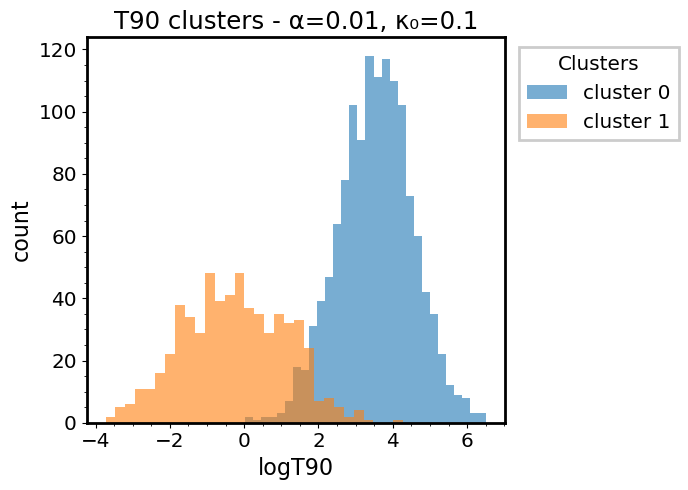

In [13]:
fig1 = plot_clustered_1d(logT90, st['assignment'], title=f"T90 clusters - α={alpha}, κ₀={kappa0}")
plt.savefig(f'../figure/gibbs_sampling/T90_cluster_alpha={alpha}_kappa0={kappa0}.png', dpi=300, bbox_inches='tight')
plt.savefig(f'../figure/gibbs_sampling/T90_cluster_alpha={alpha}_kappa0={kappa0}.pdf', dpi=300, bbox_inches='tight')
plt.show()

Con alpha=1 vengono creati molti cluster; il comportamento è probabilmente dovuto al termine della t-student, dove i valori lontani de cluster ricadono sulle code della distribuzione (che avendo un numero relativamente elevato si cmoporta come una normale, quindi con code che tendono più velocemente a 0 rispetto al t-student). Questo comporta ad un valore di $f_k(x_i)$ molto basso per valori lontani dal centro del cluster. Invece la prior predictive, che corrisponde ad un t-student con i parametri $\alpha_0$, $\beta_0$, $\kappa_0$ e $\mu_0$, pur essendo debolmente informativa rimane superiore ai valori di $f_k(x_i)$ nelle code. La prior predictive è poco informativa perché nel migliore dei casi $\sigma_k \approx 1$ (valore visibile nella distribuzione Inverse Gamma con $\alpha_0=2$ e $\beta_0=4$) il quale corrisponde ad un estrazione di $\mu_k$ in $\mathcal{N}(\mu_k|\mu_0, \sigma_k/\kappa_0 \approx 10)$, cioè con una sigma che equivale a quasi la totalità del range di dati, rendendo la distribuzione praticamente piatta con valori bassi di probabilità.

Riprovare con $\kappa_0=0.01$ per vedere se il problema persiste. Il valore basso di $\kappa_0$ implica una distribuzione di $\mathcal{N}(\mu_k|\mu_0, \sigma_k/\kappa_0)$ molto schiacciata e con valori di probabilità molto bassi (non dovrebbe superare i valori delle code di $f_k(x_i)$. Provato con $\kappa_0=0.01$, ma il problema persiste... causa ignota